In [14]:
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from xgcm import Grid

from mcs_prime.era5_calc import ERA5Calc


In [4]:


Rd = 287.06
g = 9.80665
# As used by IFS: https://confluence.ecmwf.int/display/CKB/ERA5%3A+data+documentation#ERA5:datadocumentation-SpatialreferencesystemsandEarthmodel
Re = 6371229 # m

class Era5ComputeAlt:
    """Compute geopotential (z) from netcdf data, then compute altitude (alt)

    Code taken from existing code for doing the same for GRIB data"""
    def __init__(self, ds):
        self.ds = ds
        self.e5calc = ERA5Calc('/gws/nopw/j04/mcs_prime/mmuetz/data/ERA5/ERA5_L137_model_levels_table.csv')


    def run(self):
        T = self.ds.t.values
        q = self.ds.q.values
        p = self.e5calc.calc_pressure(self.ds.lnsp.values)
        self.p = p
        zsfc = self.ds.z.values

        # Get levels in ascending order of height (starts at 137)
        levels = self.ds.level.values[::-1]
        # print(levels)

        # 0.609133 = Rv/Rd - 1.
        # virtual T
        Tv = T * (1. + 0.609133 * q) * Rd
        z_h = zsfc

        z = np.zeros_like(p)
        for lev in levels:
            lev_idx = lev - 1
            # print(lev, lev_idx)
            z_h, z_f = self.compute_z_level(lev_idx, p, Tv, z_h)
            z[lev_idx] = z_f

        h = z / g
        alt = Re * h / (Re - h)

        self.z = z
        self.h = h
        self.alt = alt
        return z, h, alt

    def compute_z_level(self, lev_idx, p, Tv, z_h):
        '''Compute z at half & full level for the given level, based on T/q/sp'''
        # compute the pressures (on half-levels)
        # ph_lev, ph_levplusone = get_ph_levs(values, lev)
        ph_lev, ph_levplusone = p[lev_idx - 1], p[lev_idx]

        if lev_idx == 0:
            dlog_p = np.log(ph_levplusone / 0.1)
            alpha = np.log(2)
        else:
            dlog_p = np.log(ph_levplusone / ph_lev)
            alpha = 1. - ((ph_lev / (ph_levplusone - ph_lev)) * dlog_p)

        # z_f is the geopotential of this full level
        # integrate from previous (lower) half-level z_h to the
        # full level
        z_f = z_h + (Tv[lev_idx] * alpha)

        # z_h is the geopotential of 'half-levels'
        # integrate z_h to next half level
        z_h = z_h + (Tv[lev_idx] * dlog_p)

        return z_h, z_f

In [6]:
era5dir = Path('/badc/ecmwf-era5/data/oper/an_ml/2020/01/01')

In [11]:
e5ds = xr.open_mfdataset(era5dir / f'ecmwf-era5_oper_an_ml_202001010000.{v}.nc' for v in ['z', 't', 'q', 'lnsp'])
e5ds

<xarray.Dataset>
Dimensions:    (longitude: 1440, latitude: 721, time: 1, level: 137)
Coordinates:
  * longitude  (longitude) float32 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * latitude   (latitude) float32 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 2020-01-01
  * level      (level) int32 1 2 3 4 5 6 7 8 ... 130 131 132 133 134 135 136 137
Data variables:
    lnsp       (time, latitude, longitude) float32 dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    q          (time, level, latitude, longitude) float32 dask.array<chunksize=(1, 137, 721, 1440), meta=np.ndarray>
    t          (time, level, latitude, longitude) float32 dask.array<chunksize=(1, 137, 721, 1440), meta=np.ndarray>
    z          (time, latitude, longitude) float32 dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-04-06 11:19:13 GMT by grib_to_netcdf-2.14.0: grib_to_n...

In [17]:
comp_alt = Era5ComputeAlt(e5ds.isel(time=0))

In [18]:
comp_alt.run()

(array([[[7.82857935e+05, 7.82857935e+05, 7.82857935e+05, ...,
          7.82857935e+05, 7.82857935e+05, 7.82857935e+05],
         [7.82824656e+05, 7.82824467e+05, 7.82824385e+05, ...,
          7.82824691e+05, 7.82824178e+05, 7.82824927e+05],
         [7.82669745e+05, 7.82669720e+05, 7.82669073e+05, ...,
          7.82668112e+05, 7.82667973e+05, 7.82668687e+05],
         ...,
         [8.12738484e+05, 8.12736980e+05, 8.12736698e+05, ...,
          8.12741921e+05, 8.12739764e+05, 8.12739247e+05],
         [8.12780462e+05, 8.12780246e+05, 8.12779420e+05, ...,
          8.12782419e+05, 8.12781706e+05, 8.12780206e+05],
         [8.12900360e+05, 8.12900360e+05, 8.12900360e+05, ...,
          8.12900360e+05, 8.12900360e+05, 8.12900360e+05]],
 
        [[7.10210839e+05, 7.10210839e+05, 7.10210839e+05, ...,
          7.10210839e+05, 7.10210839e+05, 7.10210839e+05],
         [7.10164809e+05, 7.10164620e+05, 7.10164096e+05, ...,
          7.10165192e+05, 7.10164679e+05, 7.10165080e+05],
       

In [31]:
# Create a pressure xarray.DataArray
da_p = xr.DataArray(
    comp_alt.p / 100, # convert from Pa to hPa
    dims=['level', 'latitude', 'longitude'],
    coords=dict(
        level=e5ds.q.level,
        latitude=e5ds.q.latitude,
        longitude=e5ds.q.longitude,
    ),
    attrs=dict(
        units='hPa',
        standard='air_pressure',
    )
)
# Create a geopotential xarray.DataArray
da_h = xr.DataArray(
    comp_alt.h,
    dims=['level', 'latitude', 'longitude'],
    coords=dict(
        level=e5ds.q.level,
        latitude=e5ds.q.latitude,
        longitude=e5ds.q.longitude,
    ),
    attrs=dict(
        units='m',
        standard='geopotential_height',
    )
)



In [34]:
# This is amazingly easy AND amazingly powerful.
# Interpolate u onto 19x pressure levels.
ds_p = da_p.to_dataset(name='pressure')
grid = Grid(ds_p, coords=dict(pressure={'center': 'level'}), periodic=False)
h_plev = grid.transform(
    da_h,
    'pressure',
    np.array([500]),
    target_data=ds_p.pressure,
    method='linear'
)

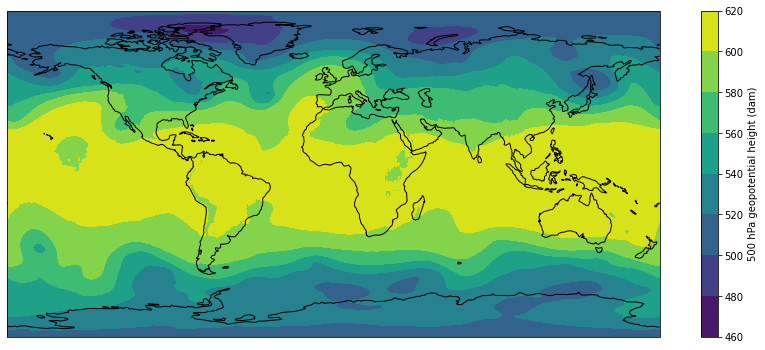

In [35]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(15, 6))

im = ax.contourf(h_plev.longitude, h_plev.latitude, h_plev.sel(pressure=500) / 10)
ax.coastlines()
plt.colorbar(im, label='500 hPa geopotential height (dam)')

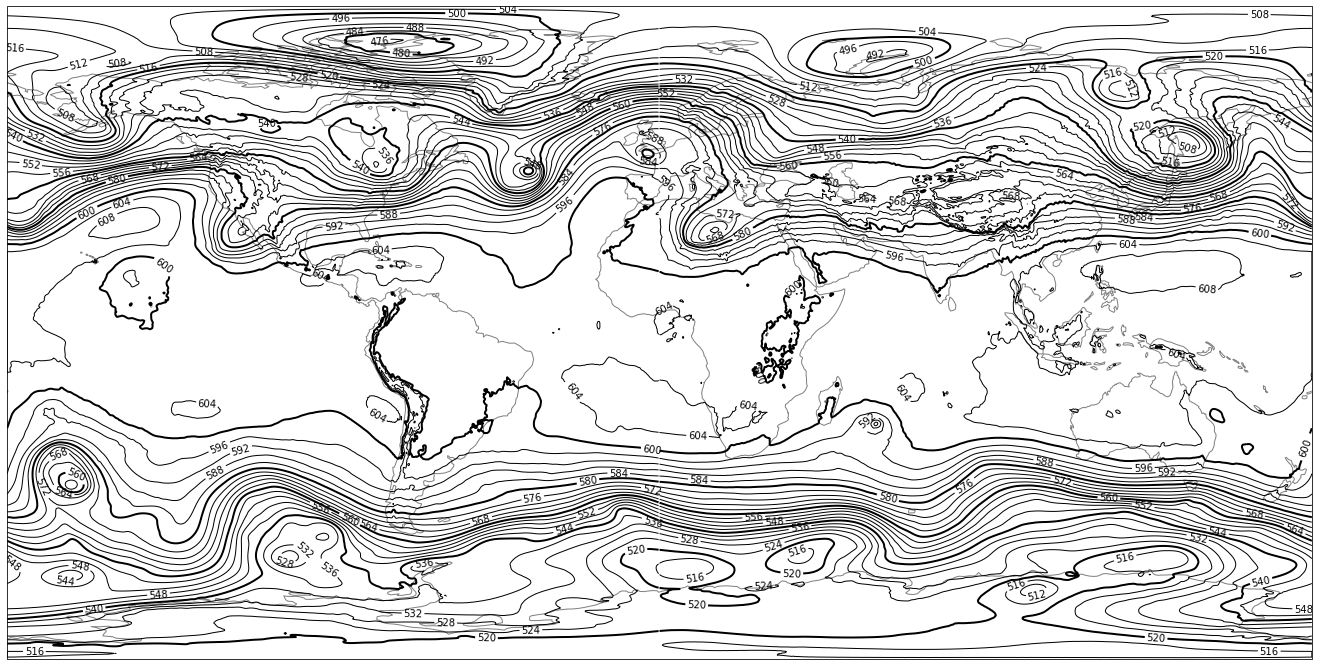

In [45]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(30, 12))
levels = np.arange(460, 624, 4)
lw = [1 if l % 20 != 0 else 2 for l in levels]
cs = ax.contour(h_plev.longitude, h_plev.latitude, h_plev.sel(pressure=500) / 10, levels=levels, linewidths=lw, colors='k')
ax.coastlines(color='grey')

def fmt(x):
    s = f"{x:.0f}"
    return s


# Basic contour plot
#fig, ax = plt.subplots()
#CS = ax.contour(X, Y, Z)

ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=10);

# plt.colorbar(im, label='500 hPa geopotential height (dam)')

In [46]:
import datetime as dt

In [50]:
dt.datetime(1, 1, 1)

datetime.datetime(1, 1, 1, 0, 0)